# Correlation, Diversification and Portfolio Stability

*Analyst Desk · The Analytical Investor · Year 1, Month 8*

**Read the article:** [Correlation, Diversification and Portfolio Stability](https://analytical-investor.blog/?p=1018)

The diversification arithmetic from the article: portfolio volatility against correlation, and how few independent bets a 'diversified' portfolio really holds.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Two assets, each 20% volatile, split 50/50

In [2]:
for rho in (1, 0.5, 0, -0.5):
    vol = np.sqrt(2 * 0.25 * 0.04 + 2 * 0.25 * rho * 0.04)
    print(f"correlation {rho:+.1f}: portfolio volatility {vol:.1%}")

correlation +1.0: portfolio volatility 20.0%
correlation +0.5: portfolio volatility 17.3%
correlation +0.0: portfolio volatility 14.1%
correlation -0.5: portfolio volatility 10.0%


## Effective number of independent bets
N_eff = N / (1 + (N - 1) * average correlation)

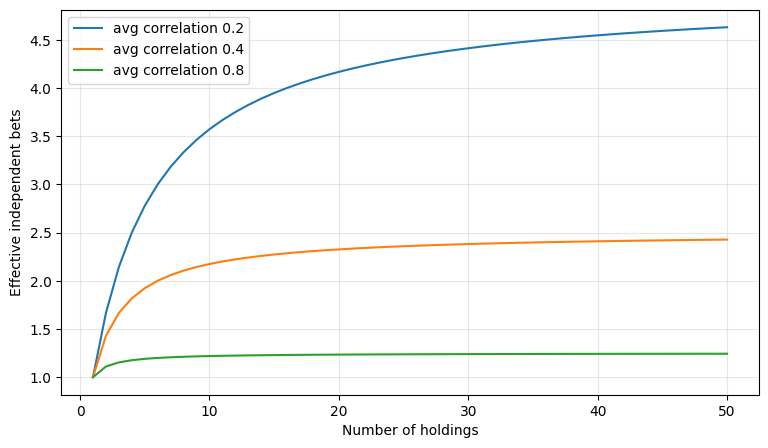

20 holdings at 0.4: 2.33 bets
30 holdings at 0.8: 1.24 bets


In [3]:
from analytical_investor.portfolio import effective_number_of_bets
N = np.arange(1, 51)
for rho in (0.2, 0.4, 0.8):
    plt.plot(N, [effective_number_of_bets(k, rho) for k in N], label=f"avg correlation {rho}")
plt.xlabel("Number of holdings"); plt.ylabel("Effective independent bets"); plt.legend(); plt.show()
print(f"20 holdings at 0.4: {effective_number_of_bets(20, 0.4):.2f} bets")
print(f"30 holdings at 0.8: {effective_number_of_bets(30, 0.8):.2f} bets")